In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)  # for reproducibility

data = {
    'StudentID': range(1, 101),
    'Score': np.random.normal(loc=75, scale=10, size=100),  # random scores around 75
    'TeachingMethod': ['Method A'] * 50 + ['Method B'] * 50  # 50 students taught by each method
}

df = pd.DataFrame(data)
df['Score'] = df['Score'].round(1)  # round scores to one decimal place
df.to_csv('student_scores.csv', index=False)


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('student_scores.csv')


In [ ]:
# Calculate the mean, median, and standard deviation of the scores for the entire dataset
mean_score = df['Score'].mean()
median_score = df['Score'].median()
std_dev_score = df['Score'].std()

print(f"Overall Mean Score: {mean_score:.2f}")
print(f"Overall Median Score: {median_score:.2f}")
print(f"Overall Standard Deviation of Scores: {std_dev_score:.2f}")

# Calculate the mean score for each teaching method
mean_scores_by_method = df.groupby('TeachingMethod')['Score'].mean()
print(mean_scores_by_method)


Overall Mean Score: 73.96
Overall Median Score: 73.70
Overall Standard Deviation of Scores: 9.08
TeachingMethod
Method A    72.752
Method B    75.174
Name: Score, dtype: float64


In [ ]:
from scipy.stats import norm

# Probability of a score above 85
prob_above_85 = 1 - norm.cdf(85, loc=mean_score, scale=std_dev_score)
print(f"Probability of a student scoring above 85: {prob_above_85:.4f}")

# Z-score of a student scoring 70
z_score_70 = (70 - mean_score) / std_dev_score
print(f"Z-score for a student scoring 70: {z_score_70:.2f}")


Probability of a student scoring above 85: 0.1121
Z-score for a student scoring 70: -0.44


In [ ]:
# Take a random sample of 30 students
sample_df = df.sample(n=30, random_state=42)
sample_mean = sample_df['Score'].mean()
sample_std_dev = sample_df['Score'].std()

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std_dev:.2f}")

# Explanation of Central Limit Theorem
print("According to the Central Limit Theorem, the distribution of the sample means will be approximately normal if we were to take many samples of size 30.")


Sample Mean: 74.51
Sample Standard Deviation: 7.54
According to the Central Limit Theorem, the distribution of the sample means will be approximately normal if we were to take many samples of size 30.


In [ ]:
from scipy.stats import ttest_ind

# Separate the scores by teaching method
scores_method_a = df[df['TeachingMethod'] == 'Method A']['Score']
scores_method_b = df[df['TeachingMethod'] == 'Method B']['Score']

# Perform an Independent Samples t-Test
t_stat, p_value = ttest_ind(scores_method_a, scores_method_b)

print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_value:.4f}")
print("If P-Value is less than 0.05, we reject the null hypothesis and conclude that there is a significant difference in scores between the two teaching methods.")


T-Statistic: -1.34
P-Value: 0.1837
If P-Value is less than 0.05, we reject the null hypothesis and conclude that there is a significant difference in scores between the two teaching methods.


In [ ]:
from scipy.stats import sem, t

# Calculate the standard error of the mean
sem_method_a = sem(scores_method_a)

# Determine the t-critical value for a 95% confidence interval
confidence_level = 0.95
degrees_freedom = len(scores_method_a) - 1
t_critical = t.ppf((1 + confidence_level) / 2, degrees_freedom)

# Calculate the margin of error
margin_error = t_critical * sem_method_a

# Calculate the confidence interval
ci_lower = mean_scores_by_method['Method A'] - margin_error
ci_upper = mean_scores_by_method['Method A'] + margin_error

print(f"95% Confidence Interval for the mean score of students taught by Method A: ({ci_lower:.2f}, {ci_upper:.2f})")


95% Confidence Interval for the mean score of students taught by Method A: (70.10, 75.40)


In [ ]:
# Random sampling
random_sample = df.sample(n=30, random_state=1)
print(random_sample.head())


    StudentID  Score TeachingMethod
80         81   72.8       Method B
84         85   66.9       Method B
33         34   64.4       Method A
81         82   78.6       Method B
93         94   71.7       Method B


In [ ]:
# Stratified sampling
stratified_sample = df.groupby('TeachingMethod', group_keys=False).apply(lambda x: x.sample(min(len(x), 15)))
print(stratified_sample.head())


    StudentID  Score TeachingMethod
17         18   78.1       Method A
12         13   77.4       Method A
19         20   60.9       Method A
9          10   80.4       Method A
6           7   90.8       Method A


In [ ]:
# For simplicity, let's assume each 10 student IDs represent a cluster.

# Define the clusters
clusters = df['StudentID'].apply(lambda x: (x - 1) // 10)

# Select 3 random clusters
selected_clusters = np.random.choice(clusters.unique(), size=3, replace=False)

# Create the cluster sample
cluster_sample = df[df['StudentID'].isin(selected_clusters)]
print(cluster_sample)


   StudentID  Score TeachingMethod
2          3   81.5       Method A
6          7   90.8       Method A
8          9   70.3       Method A


In [ ]:
# Systematic sampling
interval = len(df) // 30
start = np.random.randint(0, interval)

# Create the systematic sample
systematic_sample = df.iloc[start::interval]
print(systematic_sample.head())


    StudentID  Score TeachingMethod
0           1   80.0       Method A
3           4   90.2       Method A
6           7   90.8       Method A
9          10   80.4       Method A
12         13   77.4       Method A


In [ ]:
# Sampling error example for mean score
population_mean = df['Score'].mean()
sample_mean = random_sample['Score'].mean()
sampling_error = sample_mean - population_mean

print(f"Population Mean: {population_mean:.2f}")
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sampling Error: {sampling_error:.2f}")


Population Mean: 73.96
Sample Mean: 73.39
Sampling Error: -0.58


In [ ]:
# Demonstration of the Central Limit Theorem
sample_means = []

# Take 150 samples of size 30
for _ in range(150):
    sample = df['Score'].sample(n=30)
    sample_means.append(sample.mean())

# Convert to a pandas Series for easy statistical computation
sample_means_series = pd.Series(sample_means)

# Display the mean and standard deviation of the sampling distribution
print(f"Mean of Sampling Distribution: {sample_means_series.mean():.2f}")
print(f"STD of Sampling Distribution: {sample_means_series.std():.2f}")


Mean of Sampling Distribution: 73.83
STD of Sampling Distribution: 1.49


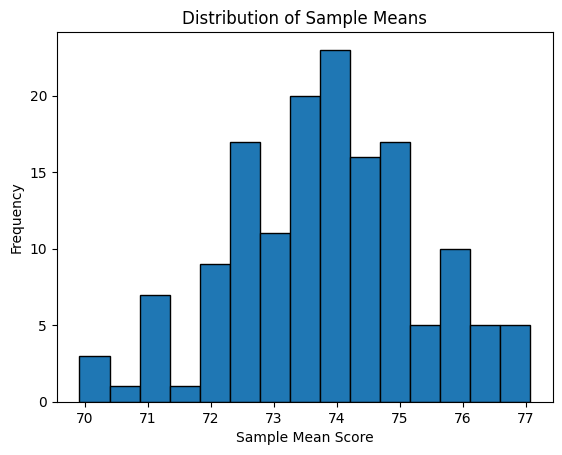

In [ ]:
import matplotlib.pyplot as plt

# Plot the distribution of sample means
plt.hist(sample_means_series, bins=15, edgecolor='black')
plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean Score')
plt.ylabel('Frequency')
plt.show()
